# Round 3 â€” Velvetfruit Extract + Vouchers

Replicates last-year (Volcanic Rock) analysis structure on this year's analogous products:

| Last year | This year |
|-----------|-----------|
| Volcanic Rock | `VELVETFRUIT_EXTRACT` (VE) |
| VR Vouchers 9500/9750/10000/10250/10500 | `VEV_4000..VEV_6500` (10 strikes) |

**Plots**
1. Underlying VE mid-price across 3 historical days.
2. Voucher mid prices vs. time, per strike.
3. **Volatility smile (all strikes, one graph)** â€” IV vs. moneyness, single parabolic fit $\hat v_t$; low-extrinsic-value outliers filtered.
4. **IV deviations (all strikes, one graph)** â€” $v_t - \hat v_t$ time series.
5. **Price deviations (all strikes, one graph)** â€” BS-reprojected deviations in price space.
6. **Autocorrelation** of VE returns vs. random baseline (mean-reversion check).
7. **Per-strike call-return autocorrelation** (IV scalping signal check).
8. **Gamma scalping EV** â€” compare realised vs. implied vol to size expected convexity profit vs. theta decay; pathwise delta-hedged P&L simulation.

**TTE mapping:** historical day 0 = 8d, day 1 = 7d, day 2 = 6d. Live Round 3 start = 5d.

Runs against `dataset/ROUND_3/`.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from math import log, sqrt, exp, erf

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

DATA = Path('..') / 'dataset' / 'ROUND_3'
DAYS = [0, 1, 2]
TTE_BY_DAY = {0: 8, 1: 7, 2: 6}  # days to expiry in historical data

STRIKES = {
    'VEV_4000': 4000, 'VEV_4500': 4500, 'VEV_5000': 5000,
    'VEV_5100': 5100, 'VEV_5200': 5200, 'VEV_5300': 5300,
    'VEV_5400': 5400, 'VEV_5500': 5500, 'VEV_6000': 6000,
    'VEV_6500': 6500,
}
UNDERLYING = 'VELVETFRUIT_EXTRACT'

# Consistent color per strike for every plot in the notebook
cmap = plt.cm.viridis
sorted_strikes = sorted(STRIKES.items(), key=lambda x: x[1])
STRIKE_COLOR = {
    sym: cmap(i / max(1, len(STRIKES) - 1))
    for i, (sym, _) in enumerate(sorted_strikes)
}

print(f"Data dir: {DATA.resolve()}")
print(f"Strikes: {sorted(STRIKES.values())}")

Data dir: C:\Users\fogat\Desktop\imc_trading\dataset\ROUND_3
Strikes: [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]


In [44]:
# Load prices for all 3 historical days, stitch with a continuous time axis.
TICKS_PER_DAY = 10_000  # Prosperity: 1 tick per 100ms, 1M ms/day

frames = []
for d in DAYS:
    f = DATA / f'prices_round_3_day_{d}.csv'
    df = pd.read_csv(f, sep=';')
    df['day'] = d
    df['tte_days'] = TTE_BY_DAY[d]
    df['t_global'] = d * TICKS_PER_DAY + df['timestamp'] / 100  # continuous tick count
    frames.append(df)
prices = pd.concat(frames, ignore_index=True)
# Drop HYDROGEL_PACK â€” not analysed in this notebook
prices = prices[prices['product'] != 'HYDROGEL_PACK']
print(prices.shape)
print(prices['product'].value_counts())

(330000, 19)
product
VEV_5400               30000
VEV_6500               30000
VEV_5500               30000
VEV_5200               30000
VEV_5300               30000
VELVETFRUIT_EXTRACT    30000
VEV_4500               30000
VEV_5000               30000
VEV_4000               30000
VEV_5100               30000
VEV_6000               30000
Name: count, dtype: int64


In [45]:
# Pivot to per-product mid-price time series (indexed on t_global).
mid = (
    prices.pivot_table(index='t_global', columns='product', values='mid_price', aggfunc='first')
          .sort_index()
)
print(mid.shape)
mid.head()

(30000, 11)


product,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
t_global,,,,,,,,,,,
0.0,5250.0,1250.0,750.0,257.0,171.5,101.5,53.0,23.0,8.5,0.5,0.5
1.0,5250.5,1250.5,751.0,258.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
2.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
3.0,5250.5,1250.5,750.0,257.5,172.0,102.5,53.0,23.5,8.5,0.5,0.5
4.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5


## 1. Underlying VE price path

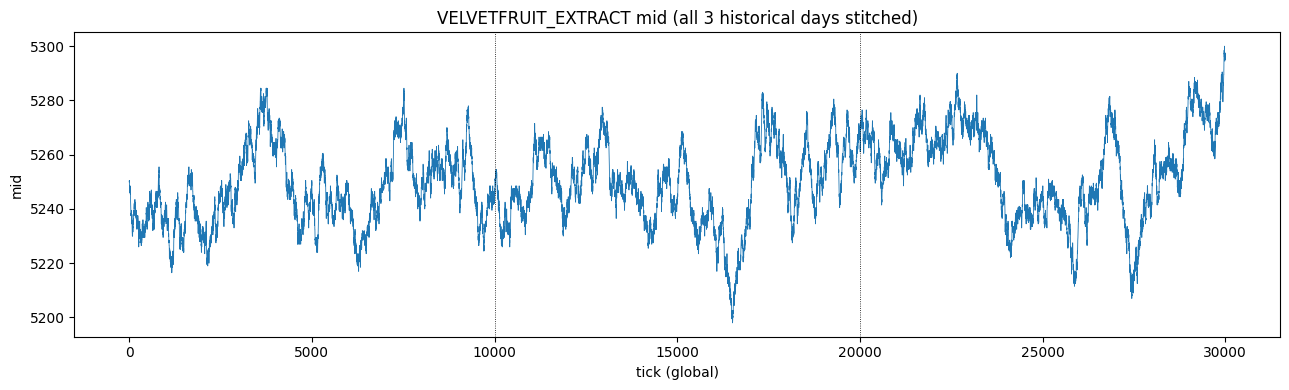

In [46]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(mid.index, mid[UNDERLYING], lw=0.6, color='tab:blue')
ax.set_title('VELVETFRUIT_EXTRACT mid (all 3 historical days stitched)')
ax.set_ylabel('mid')
for d in DAYS[1:]:
    ax.axvline(d * TICKS_PER_DAY, color='k', ls=':', lw=0.6)
ax.set_xlabel('tick (global)')
plt.tight_layout(); plt.show()

## 2. Voucher mid prices vs. time

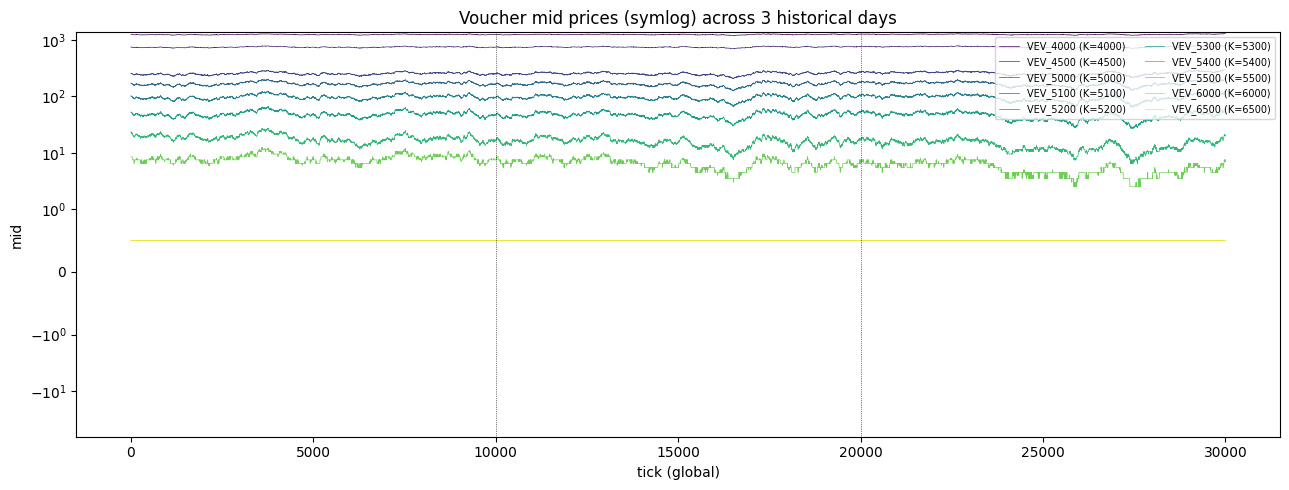

In [47]:
fig, ax = plt.subplots(figsize=(13, 5))
for sym, K in sorted_strikes:
    if sym in mid.columns:
        ax.plot(mid.index, mid[sym], lw=0.5, label=f'{sym} (K={K})', color=STRIKE_COLOR[sym])
for d in DAYS[1:]:
    ax.axvline(d * TICKS_PER_DAY, color='k', ls=':', lw=0.5)
ax.set_yscale('symlog', linthresh=1)
ax.set_title('Voucher mid prices (symlog) across 3 historical days')
ax.set_xlabel('tick (global)'); ax.set_ylabel('mid')
ax.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout(); plt.show()

## 3. Black-Scholes helpers and IV solver

In [48]:
SQRT2 = np.sqrt(2.0)

def _norm_cdf(x):
    return 0.5 * (1.0 + np.vectorize(erf)(x / SQRT2))

def _norm_pdf(x):
    return np.exp(-0.5 * np.asarray(x) ** 2) / np.sqrt(2 * np.pi)

def bs_call(S, K, T, sigma, r=0.0):
    """Black-Scholes call price. S,K > 0, T > 0, sigma > 0."""
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    vt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * vt * vt) / vt
    d2 = d1 - vt
    return S * _norm_cdf(d1) - K * np.exp(-r * T) * _norm_cdf(d2)

def bs_vega(S, K, T, sigma, r=0.0):
    S = float(S); K = float(K); T = float(T); sigma = float(sigma)
    vt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * vt * vt) / vt
    return S * _norm_pdf(d1) * np.sqrt(T)

def bs_greeks(S, K, T, sigma, r=0.0):
    """Return (delta, gamma, theta_per_year, vega) for a call."""
    S = np.asarray(S, dtype=float); K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float); sigma = np.asarray(sigma, dtype=float)
    vt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * vt * vt) / vt
    d2 = d1 - vt
    delta = _norm_cdf(d1)
    pdf_d1 = _norm_pdf(d1)
    gamma = pdf_d1 / (S * vt)
    theta = -(S * pdf_d1 * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * _norm_cdf(d2)
    vega = S * pdf_d1 * np.sqrt(T)
    return delta, gamma, theta, vega

def implied_vol_call(price, S, K, T, r=0.0, lo=1e-4, hi=3.0, tol=1e-8, max_iter=80):
    """Robust IV solver - bisection bracket + Newton polish.

    Rejects with NaN when the quote gives no information about sigma:
    - price below intrinsic (arbitrage-violating or stale quote),
    - price <= 0 or non-finite,
    - price above the sigma=hi BS call value (off-the-chart IV),
    - price so close to intrinsic that bs_call is effectively flat in sigma
      near lo (the BS curve has zero curvature there, any sigma fits).
    """
    if not np.isfinite(price) or price <= 0:
        return np.nan
    intrinsic = max(0.0, S - K * exp(-r * T))
    upper = float(bs_call(S, K, T, hi, r))
    if price < intrinsic - 1e-8:
        return np.nan
    if price > upper:
        return np.nan
    lower_val = float(bs_call(S, K, T, lo, r))
    if price - lower_val < tol:
        return np.nan

    a, b = lo, hi
    for _ in range(max_iter):
        mid_s = 0.5 * (a + b)
        f = float(bs_call(S, K, T, mid_s, r)) - price
        if abs(f) < tol:
            a = b = mid_s
            break
        if f > 0:
            b = mid_s
        else:
            a = mid_s
    sigma = 0.5 * (a + b)
    for _ in range(3):
        v = bs_vega(S, K, T, sigma, r)
        if v < 1e-10:
            break
        diff = float(bs_call(S, K, T, sigma, r)) - price
        sigma -= diff / v
        if not (lo < sigma < hi):
            sigma = 0.5 * (a + b)
            break
    return sigma

print('ATM 5000/5000 1y @ 20% vol:', bs_call(5000, 5000, 1.0, 0.20))
print('Recovered IV (ATM):', implied_vol_call(bs_call(5000, 5000, 1.0, 0.20), 5000, 5000, 1.0))
print('Deep-ITM at intrinsic (should be NaN):',
      implied_vol_call(1250.0, 5250.0, 4000.0, 6/365))
print('Far-OTM 0.5 price (should be NaN):',
      implied_vol_call(0.5, 5250.0, 6500.0, 6/365))

ATM 5000/5000 1y @ 20% vol: 398.27837277028993
Recovered IV (ATM): 0.20000000000000004
Deep-ITM at intrinsic (should be NaN): nan
Far-OTM 0.5 price (should be NaN): 0.6182895517778032


## 4. Per-tick IV surface

**Rigorous IV construction.** The solver `implied_vol_call` now:
- rejects quotes below intrinsic, above the sigma=3 BS price, or <= 0;
- **rejects near-intrinsic prices** where `bs_call(sigma=lo) ~= price` - there the call curve is flat in sigma, so any sigma in a wide range fits and the "IV" is meaningless;
- bisects to a tight price tolerance, then polishes with 3 Newton steps.

**Moneyness convention.** $m_t = \ln(S/K)/\sqrt{T}$. Note this includes $\sqrt{T}$, so the *same strike on different days* lands at slightly different $m$ because TTE drops 8d -> 7d -> 6d. We therefore also fit the smile **per day** in sec. 5 to check stability across TTE, not only a single pooled fit.

**Time unit.** `T_years = tte_days / 365` is a convention; the smile shape and the detrended deviations are invariant to this choice - only the *level* of sigma scales. Everything downstream (greeks, gamma scalping EV) stays consistent because we use the same T everywhere.

In [49]:
# Build long-format: one row per (t_global, strike) with S, K, C, T, IV, moneyness, extrinsic.
voucher_syms = [s for s in STRIKES if s in mid.columns]
S_series = mid[UNDERLYING]

tick_to_tte = (
    prices[['t_global', 'tte_days']].drop_duplicates('t_global').set_index('t_global')['tte_days']
)

DOWN = 10  # downsample to every 10th tick for IV-solver speed
idx = mid.index[::DOWN]

rows = []
for t in idx:
    S = S_series.get(t, np.nan)
    if not np.isfinite(S):
        continue
    tte_d = tick_to_tte.get(t, np.nan)
    if not np.isfinite(tte_d):
        continue
    T = float(tte_d) / 365.0
    for sym in voucher_syms:
        C = mid.at[t, sym] if sym in mid.columns else np.nan
        if not np.isfinite(C):
            continue
        K = STRIKES[sym]
        intrinsic = max(0.0, S - K)
        extrinsic = float(C) - intrinsic
        iv = implied_vol_call(float(C), float(S), float(K), T)
        m = np.log(S / K) / np.sqrt(T)
        rows.append((t, sym, K, S, float(C), T, m, iv, extrinsic))

ivdf = pd.DataFrame(rows, columns=['t_global', 'symbol', 'K', 'S', 'C', 'T', 'm', 'iv', 'extrinsic'])
ivdf['day'] = (ivdf['t_global'] // TICKS_PER_DAY).astype(int)

diag = ivdf.groupby('symbol').agg(
    n_obs=('iv', 'size'),
    n_iv_valid=('iv', lambda s: int(s.notna().sum())),
    iv_mean=('iv', 'mean'),
    iv_std=('iv', 'std'),
    extrinsic_mean=('extrinsic', 'mean'),
).reindex([s for s, _ in sorted_strikes])
print(f'Total rows: {len(ivdf)}  ({ivdf["iv"].notna().sum()} with valid IV after robust solver)')
print(diag)

Total rows: 30000  (25132 with valid IV after robust solver)
          n_obs  n_iv_valid   iv_mean    iv_std  extrinsic_mean
symbol                                                         
VEV_4000   3000         310  0.790662  0.089512        0.005333
VEV_4500   3000         825  0.450173  0.043416       -0.008833
VEV_5000   3000        2997  0.232830  0.008409        4.908833
VEV_5100   3000        3000  0.230697  0.007547       16.695000
VEV_5200   3000        3000  0.233304  0.006228       45.443167
VEV_5300   3000        3000  0.235791  0.005566       46.744000
VEV_5400   3000        3000  0.221131  0.007113       15.953500
VEV_5500   3000        3000  0.239831  0.006202        6.639833
VEV_6000   3000        3000  0.379621  0.021852        0.500000
VEV_6500   3000        3000  0.575250  0.032921        0.500000


## 5. Volatility smile - all strikes on one graph

Scatter of implied vol $v_t$ vs. moneyness $m_t$ across all strikes. A parabola is fitted to produce $\hat v_t$ - the "fair" IV given $m_t$.

**Rigorous outlier filter** applied per row, three criteria combined:
1. `iv` must be finite (the robust solver in sec. 3 already rejects near-intrinsic ambiguity).
2. `extrinsic > max(3.0, 0.003 * S)` - at least 3 SeaShells of time value, or 0.3% of S.
3. `C >= 2.0` - minimum premium; with 0.5-tick discretization, IV below this threshold is dominated by price quantization noise.

**Per-day fits vs. pooled fit.** Because $m_t$ includes $\sqrt{T}$ and TTE changes 8d->7d->6d across historical days, the same strike lands at different $m$ each day. We fit the parabola both per-day (to check smile stability across TTE) and pooled.

Kept 9321 / 30000 rows (31.1%) after rigorous filter.
Rows kept per strike:
symbol
VEV_4000       0
VEV_4500       0
VEV_5000       0
VEV_5100    1654
VEV_5200    3000
VEV_5300    3000
VEV_5400    1667
VEV_5500       0
VEV_6000       0
VEV_6500       0
dtype: int64

Pooled fit:      a=-0.1484  b=+0.0202  c=+0.2349
Day 0 (TTE=8d): a=-0.0354  b=+0.0288  c=+0.2319
Day 1 (TTE=7d): a=-0.2408  b=+0.0148  c=+0.2376
Day 2 (TTE=6d): a=-0.4079  b=-0.0064  c=+0.2369


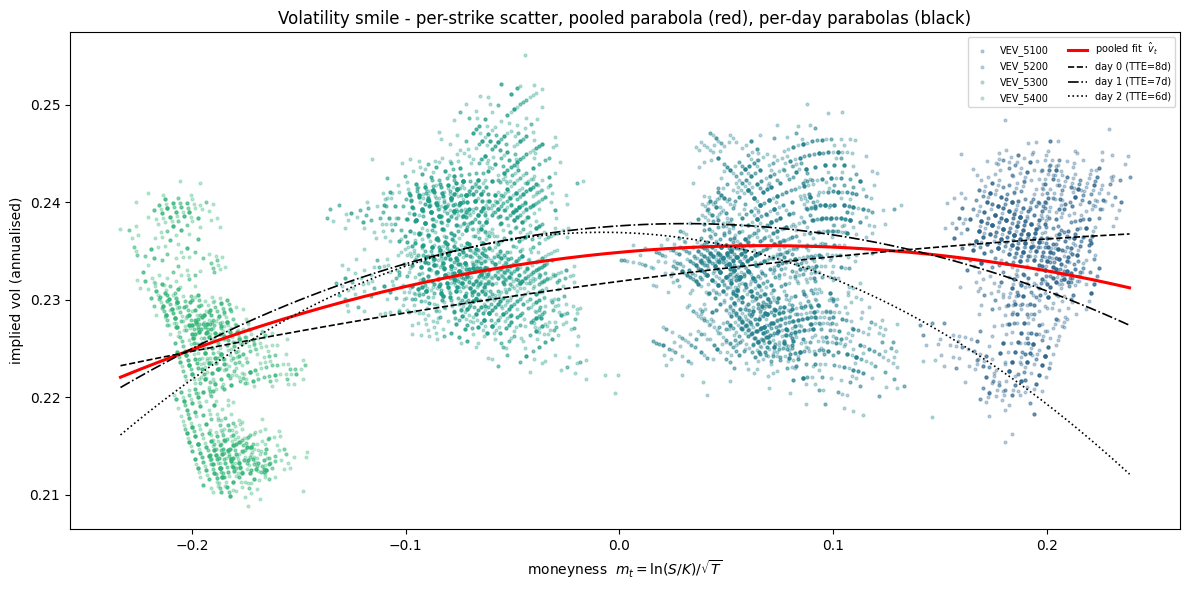

In [50]:
def smile_mask(df):
    return (
        df['iv'].notna()
        & (df['extrinsic'] > np.maximum(3.0, 0.003 * df['S']))
        & (df['C'] >= 2.0)
    )

mask = smile_mask(ivdf)
ivdf_clean = ivdf[mask].copy()
print(f'Kept {len(ivdf_clean)} / {len(ivdf)} rows '
      f'({100 * len(ivdf_clean) / len(ivdf):.1f}%) after rigorous filter.')
print('Rows kept per strike:')
print(ivdf_clean.groupby('symbol').size().reindex([s for s, _ in sorted_strikes]).fillna(0).astype(int))

fit_by_day = {}
for d in DAYS:
    sub = ivdf_clean[ivdf_clean['day'] == d]
    if len(sub) < 10:
        continue
    fit_by_day[d] = np.polyfit(sub['m'], sub['iv'], 2)

coef_pool = np.polyfit(ivdf_clean['m'], ivdf_clean['iv'], 2)

print(f"\nPooled fit:      a={coef_pool[0]:+.4f}  b={coef_pool[1]:+.4f}  c={coef_pool[2]:+.4f}")
for d, c in fit_by_day.items():
    print(f"Day {d} (TTE={TTE_BY_DAY[d]}d): a={c[0]:+.4f}  b={c[1]:+.4f}  c={c[2]:+.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
for sym, K in sorted_strikes:
    sub = ivdf_clean[ivdf_clean['symbol'] == sym]
    if sub.empty:
        continue
    ax.scatter(sub['m'], sub['iv'], s=4, alpha=0.3, color=STRIKE_COLOR[sym], label=f'{sym}')

mgrid = np.linspace(ivdf_clean['m'].min(), ivdf_clean['m'].max(), 300)
ax.plot(mgrid, np.polyval(coef_pool, mgrid),
        color='red', lw=2.2, label='pooled fit  $\\hat v_t$')
day_styles = {0: '--', 1: '-.', 2: ':'}
for d, c in fit_by_day.items():
    ax.plot(mgrid, np.polyval(c, mgrid),
            color='black', lw=1.2, ls=day_styles.get(d, '--'),
            label=f'day {d} (TTE={TTE_BY_DAY[d]}d)')

ax.set_xlabel('moneyness  $m_t = \\ln(S/K)/\\sqrt{T}$')
ax.set_ylabel('implied vol (annualised)')
ax.set_title('Volatility smile - per-strike scatter, pooled parabola (red), per-day parabolas (black)')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

coef = coef_pool  # downstream cells expect `coef`

### Smile-fit diagnostics

Two sanity plots:
1. **Mean IV per strike** (with +/- 1 sigma bars). If all bars cluster tightly, the observed "smile" is really strike-to-strike level variation and the parabola is fitting mean-per-strike rather than within-strike curvature. The old strategy's edge comes from *residuals* around the fit, so what matters is the residual distribution being tight and mean-zero, not a dramatic smile.
2. **Residual histogram** $v_t - \hat v_t$. Should be roughly symmetric and centered on zero. Heavy tails or asymmetry = fit is biased and `iv_dev` signals would be unreliable.

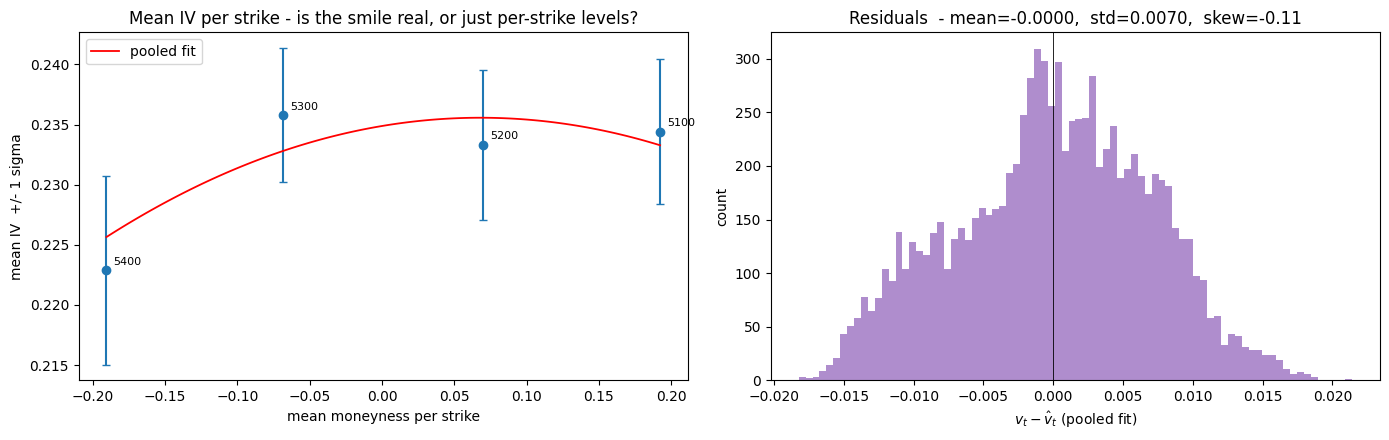


Mean-IV-per-strike summary:
             K     n    m_mean   iv_mean    iv_std
symbol                                            
VEV_5100  5100  1654  0.192269  0.234425  0.006062
VEV_5200  5200  3000  0.069863  0.233304  0.006228
VEV_5300  5300  3000 -0.068397  0.235791  0.005566
VEV_5400  5400  1667 -0.190528  0.222887  0.007852


In [51]:
strike_stats = (
    ivdf_clean.groupby('symbol')
              .agg(m_mean=('m', 'mean'), iv_mean=('iv', 'mean'), iv_std=('iv', 'std'),
                   n=('iv', 'size'), K=('K', 'first'))
              .sort_values('K')
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.errorbar(strike_stats['m_mean'], strike_stats['iv_mean'],
            yerr=strike_stats['iv_std'], fmt='o', capsize=3, color='tab:blue')
for sym, row in strike_stats.iterrows():
    ax.annotate(sym.replace('VEV_', ''), (row['m_mean'], row['iv_mean']),
                textcoords='offset points', xytext=(5, 4), fontsize=8)
mgrid = np.linspace(strike_stats['m_mean'].min(), strike_stats['m_mean'].max(), 100)
ax.plot(mgrid, np.polyval(coef_pool, mgrid), color='red', lw=1.3, label='pooled fit')
ax.set_xlabel('mean moneyness per strike'); ax.set_ylabel('mean IV  +/- 1 sigma')
ax.set_title('Mean IV per strike - is the smile real, or just per-strike levels?')
ax.legend()

ivdf_clean['iv_resid_pool'] = ivdf_clean['iv'] - np.polyval(coef_pool, ivdf_clean['m'])
ax = axes[1]
ax.hist(ivdf_clean['iv_resid_pool'], bins=80, color='tab:purple', alpha=0.75)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('$v_t - \\hat v_t$ (pooled fit)'); ax.set_ylabel('count')
r = ivdf_clean['iv_resid_pool']
ax.set_title(f'Residuals  - mean={r.mean():+.4f},  std={r.std():.4f},  skew={r.skew():+.2f}')
plt.tight_layout(); plt.show()

print('\nMean-IV-per-strike summary:')
print(strike_stats[['K', 'n', 'm_mean', 'iv_mean', 'iv_std']])

## 6. IV deviations $v_t - \hat v_t$ â€” all strikes on one graph

After subtracting the fitted smile, residuals are moneyness-independent. Short-term patterns here = relative option mispricing signal. Each strike is plotted in its own color on a shared axis.

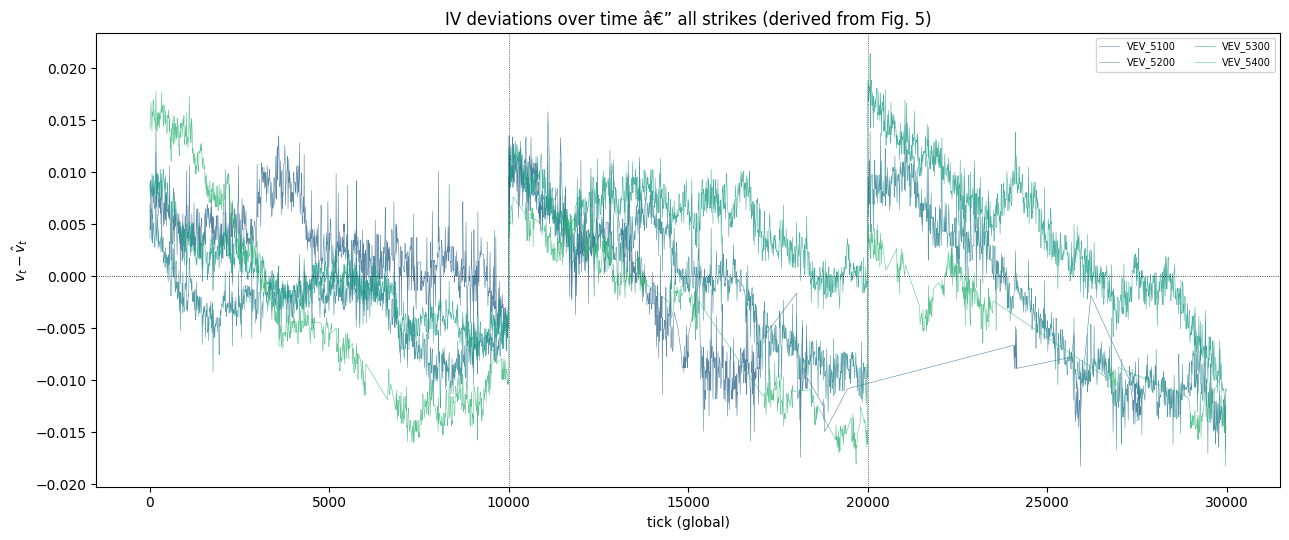

Summary per strike (iv_dev):
           count      mean       std
symbol                              
VEV_4000     NaN       NaN       NaN
VEV_4500     NaN       NaN       NaN
VEV_5000     NaN       NaN       NaN
VEV_5100  1654.0  0.001187  0.006227
VEV_5200  3000.0 -0.002186  0.006222
VEV_5300  3000.0  0.003049  0.005663
VEV_5400  1667.0 -0.002731  0.008557
VEV_5500     NaN       NaN       NaN
VEV_6000     NaN       NaN       NaN
VEV_6500     NaN       NaN       NaN


In [52]:
ivdf_clean['iv_fit'] = np.polyval(coef, ivdf_clean['m'])
ivdf_clean['iv_dev'] = ivdf_clean['iv'] - ivdf_clean['iv_fit']

fig, ax = plt.subplots(figsize=(13, 5.5))
for sym, K in sorted_strikes:
    sub = ivdf_clean[ivdf_clean['symbol'] == sym].sort_values('t_global')
    if sub.empty:
        continue
    ax.plot(sub['t_global'], sub['iv_dev'], lw=0.4, alpha=0.8,
            color=STRIKE_COLOR[sym], label=f'{sym}')
ax.axhline(0, color='k', ls=':', lw=0.6)
for d in DAYS[1:]:
    ax.axvline(d * TICKS_PER_DAY, color='k', ls=':', lw=0.5)
ax.set_xlabel('tick (global)'); ax.set_ylabel('$v_t - \\hat v_t$')
ax.set_title('IV deviations over time â€” all strikes (derived from Fig. 5)')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

print('Summary per strike (iv_dev):')
print(ivdf_clean.groupby('symbol')['iv_dev'].agg(['count', 'mean', 'std']).reindex([s for s,_ in sorted_strikes]))

## 7. Price-space deviations â€” all strikes on one graph

Same IV deviations as Â§6, transformed into price space via Black-Scholes: $C_{\text{mkt}} - C(\hat v_t)$. More intuitive view of relative mispricings over time â€” units are SeaShells, directly comparable to quote sizes.

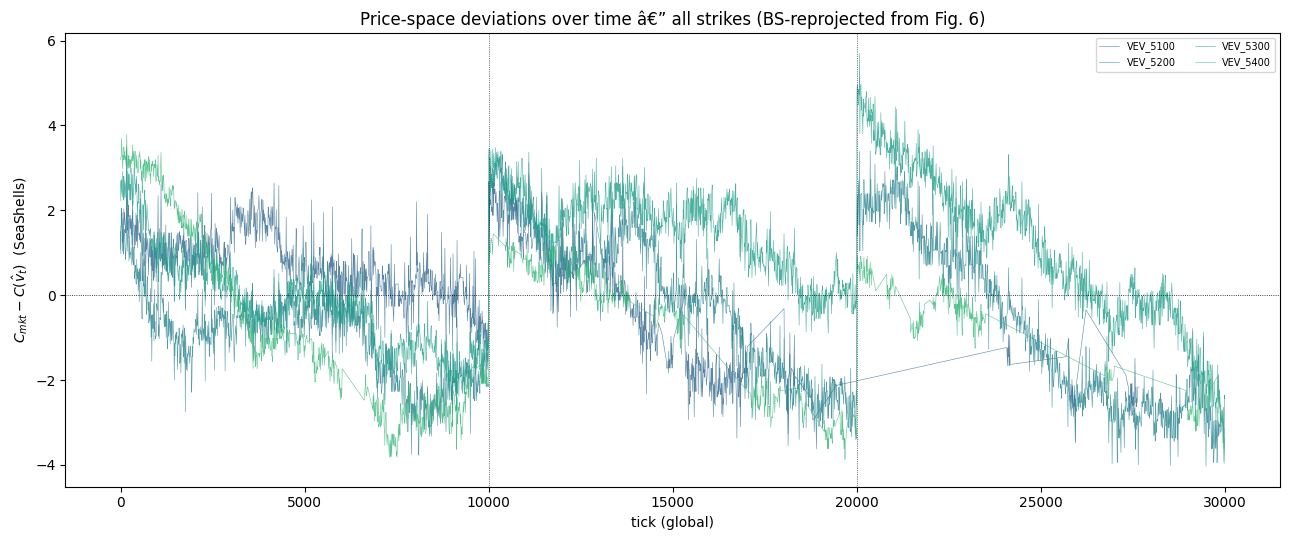

Summary per strike (C_dev):
           count      mean       std
symbol                              
VEV_4000     NaN       NaN       NaN
VEV_4500     NaN       NaN       NaN
VEV_5000     NaN       NaN       NaN
VEV_5100  1654.0  0.264196  1.284168
VEV_5200  3000.0 -0.597584  1.642967
VEV_5300  3000.0  0.809009  1.545129
VEV_5400  1667.0 -0.611763  1.818477
VEV_5500     NaN       NaN       NaN
VEV_6000     NaN       NaN       NaN
VEV_6500     NaN       NaN       NaN


In [53]:
ivdf_clean['C_fit'] = bs_call(
    ivdf_clean['S'].values, ivdf_clean['K'].values,
    ivdf_clean['T'].values, ivdf_clean['iv_fit'].values,
)
ivdf_clean['C_dev'] = ivdf_clean['C'] - ivdf_clean['C_fit']

fig, ax = plt.subplots(figsize=(13, 5.5))
for sym, K in sorted_strikes:
    sub = ivdf_clean[ivdf_clean['symbol'] == sym].sort_values('t_global')
    if sub.empty:
        continue
    ax.plot(sub['t_global'], sub['C_dev'], lw=0.4, alpha=0.8,
            color=STRIKE_COLOR[sym], label=f'{sym}')
ax.axhline(0, color='k', ls=':', lw=0.6)
for d in DAYS[1:]:
    ax.axvline(d * TICKS_PER_DAY, color='k', ls=':', lw=0.5)
ax.set_xlabel('tick (global)'); ax.set_ylabel('$C_{mkt} - C(\\hat v_t)$  (SeaShells)')
ax.set_title('Price-space deviations over time â€” all strikes (BS-reprojected from Fig. 6)')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

print('Summary per strike (C_dev):')
print(ivdf_clean.groupby('symbol')['C_dev'].agg(['count', 'mean', 'std']).reindex([s for s,_ in sorted_strikes]))

## 8. Underlying autocorrelation â€” mean-reversion check

Same test as old strategy: autocorrelation of VE returns vs. a random-normal baseline.

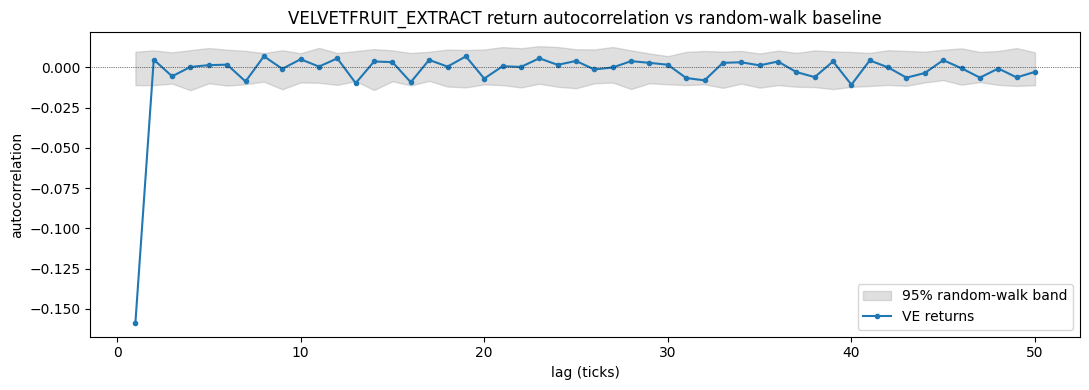

lag-1 autocorr: -0.1588
mean abs autocorr 1..10: 0.0194


In [54]:
rets = mid[UNDERLYING].pct_change().dropna()

def autocorr(x, lags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    denom = np.dot(x, x)
    if denom == 0 or not np.isfinite(denom):
        return np.full(len(lags), np.nan)
    out = np.empty(len(lags))
    for i, k in enumerate(lags):
        if k <= 0 or k >= n:
            out[i] = np.nan
        else:
            out[i] = np.dot(x[:-k], x[k:]) / denom
    return out

lags = np.arange(1, 51)
ac_real = autocorr(rets.values, lags)

rng = np.random.default_rng(0)
baseline = np.array([
    autocorr(rng.normal(0, rets.std(), size=len(rets)), lags) for _ in range(100)
])
lo, hi = np.quantile(baseline, [0.025, 0.975], axis=0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(lags, lo, hi, color='gray', alpha=0.25, label='95% random-walk band')
ax.plot(lags, ac_real, marker='o', ms=3, color='tab:blue', label='VE returns')
ax.axhline(0, color='k', ls=':', lw=0.5)
ax.set_xlabel('lag (ticks)'); ax.set_ylabel('autocorrelation')
ax.set_title('VELVETFRUIT_EXTRACT return autocorrelation vs random-walk baseline')
ax.legend(); plt.tight_layout(); plt.show()

print(f'lag-1 autocorr: {ac_real[0]:+.4f}')
print(f'mean abs autocorr 1..10: {np.nanmean(np.abs(ac_real[:10])):.4f}')

## 9. Per-strike return autocorrelation (scalping signal check)

Old strategy relied on negative lag-1 autocorrelation in **call-price** returns as justification for IV scalping. Compute it per strike. Strikes with a flat price path (always near zero) produce NaN and are not scalpable.

In [55]:
rows = []
for sym, K in sorted_strikes:
    if sym not in mid.columns:
        continue
    series = mid[sym].dropna()
    if len(series) < 200:
        continue
    r = series.pct_change().dropna().values
    ac1 = autocorr(r, [1])[0]
    rows.append({'symbol': sym, 'K': K, 'n': len(r), 'ac_lag1': ac1})
ac_df = pd.DataFrame(rows).sort_values('K')
ac_df

,symbol,K,n,ac_lag1
0,VEV_4000,4000,29999,-0.284426
1,VEV_4500,4500,29999,-0.225129
2,VEV_5000,5000,29999,-0.099564
3,VEV_5100,5100,29999,-0.098016
4,VEV_5200,5200,29999,-0.134874
5,VEV_5300,5300,29999,-0.219789
6,VEV_5400,5400,29999,-0.249981
7,VEV_5500,5500,29999,-0.241230
8,VEV_6000,6000,29999,NaN
9,VEV_6500,6500,29999,NaN


## 10. Gamma scalping â€” expected value

**Setup.** Buy 1 call, continuously delta-hedge by shorting $\Delta \cdot S$ of the underlying. The instantaneous P&L of this delta-neutral book is:

$$
d\Pi \;=\; \tfrac{1}{2}\,\Gamma\,(dS)^2 \;+\; \Theta\,dt
$$

(higher-order terms ignored; $\Theta$ is negative for a long option).

Taking expectations, $\mathbb{E}[(dS)^2] = \sigma_{\text{real}}^2 S^2 \, dt$, and under Black-Scholes $\Theta = -\tfrac{1}{2}\Gamma S^2 \sigma_{\text{impl}}^2$ (zero rates), giving:

$$
\mathbb{E}[d\Pi] \;=\; \tfrac{1}{2}\,\Gamma\,S^2\,(\sigma_{\text{real}}^2 - \sigma_{\text{impl}}^2)\,dt
$$

**Conclusion:** gamma scalping is **positive EV iff realised vol > implied vol**. The underlying price moves provide convexity gains that outweigh theta decay precisely when the market under-prices volatility.

### Realised vol estimate

In [56]:
# Annualisation: 1 Prosperity day = 1/365 year, so ticks/year = 10_000 * 365.
TICKS_PER_YEAR = TICKS_PER_DAY * 365

log_rets = np.log(mid[UNDERLYING]).diff().dropna()
sigma_tick = log_rets.std()
sigma_real_annual = sigma_tick * np.sqrt(TICKS_PER_YEAR)
print(f'Per-tick log-return std: {sigma_tick:.6f}')
print(f'Annualised realised vol (pooled 3 days): {sigma_real_annual:.4f}')

per_day = log_rets.groupby((log_rets.index // TICKS_PER_DAY).astype(int)).std() * np.sqrt(TICKS_PER_YEAR)
per_day.index.name = 'day'
per_day.name = 'sigma_realised_annual'
print('\nPer-day realised vol:')
print(per_day)

Per-tick log-return std: 0.000215
Annualised realised vol (pooled 3 days): 0.4117

Per-day realised vol:
day
0    0.408057
1    0.413111
2    0.413815
Name: sigma_realised_annual, dtype: float64


          sigma_impl_mean  sigma_realised      edge  edge_var     K
symbol                                                             
VEV_5100         0.234425        0.411656  0.177231  0.114505  5100
VEV_5200         0.233304        0.411656  0.178352  0.115030  5200
VEV_5300         0.235791        0.411656  0.175865  0.113863  5300
VEV_5400         0.222887        0.411656  0.188769  0.119782  5400


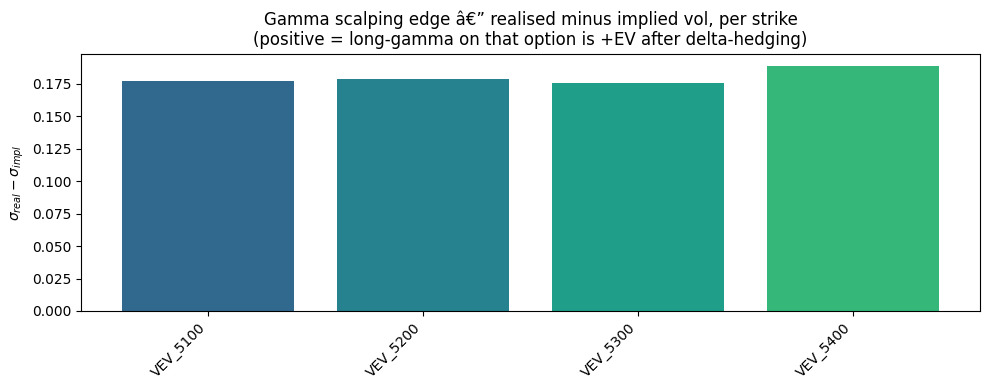

In [57]:
# Compare realised vs implied per strike (mean IV across ticks).
iv_mean = ivdf_clean.groupby('symbol')['iv'].mean().rename('sigma_impl_mean')
comp = pd.DataFrame({'sigma_impl_mean': iv_mean})
comp['sigma_realised'] = sigma_real_annual
comp['edge'] = comp['sigma_realised'] - comp['sigma_impl_mean']
comp['edge_var'] = comp['sigma_realised'] ** 2 - comp['sigma_impl_mean'] ** 2
comp['K'] = comp.index.map(STRIKES)
comp = comp.sort_values('K')
print(comp)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(comp)), comp['edge'], color=[STRIKE_COLOR[s] for s in comp.index])
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(range(len(comp)))
ax.set_xticklabels(comp.index, rotation=45, ha='right')
ax.set_ylabel(r'$\sigma_{real} - \sigma_{impl}$')
ax.set_title('Gamma scalping edge â€” realised minus implied vol, per strike\n(positive = long-gamma on that option is +EV after delta-hedging)')
plt.tight_layout(); plt.show()

### Pathwise EV estimate (tick-by-tick delta-hedged P&L)

Instead of the theoretical formula, simulate actual delta-hedged P&L tick-by-tick on the historical data. For each strike, hold 1 long call throughout. At every tick:
1. Compute delta using the **fitted** smile vol $\hat v_t$ (so the hedge doesn't chase IV noise).
2. Realise P&L of the call: $\Delta C$.
3. Realise P&L of the short-delta underlying hedge: $-\Delta_{t-1} \cdot \Delta S$.

Sum â†’ total gamma-scalping P&L per strike over 3 historical days, 1 contract.

     symbol       K  n_steps    pnl_sum  pnl_mean_per_step  pnl_std_per_step  avg_gamma  avg_theta_per_tick
0  VEV_5100  5100.0     1653   1.323598           0.000801          0.590405   0.001593           -0.000326
1  VEV_5200  5200.0     2999  17.309411           0.005772          0.523994   0.002219           -0.000465
2  VEV_5300  5300.0     2999  16.354430           0.005453          0.424725   0.002270           -0.000465
3  VEV_5400  5400.0     1666   1.025042           0.000615          0.262099   0.001691           -0.000326


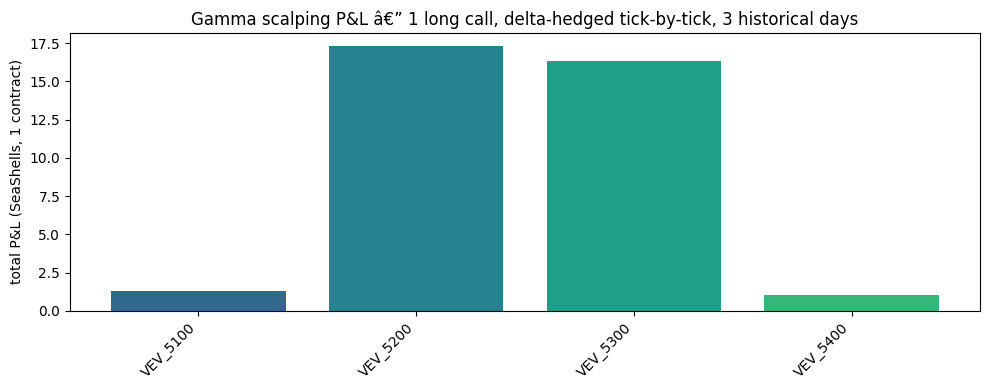

In [58]:
def gamma_scalp_pnl(sym):
    sub = ivdf_clean[ivdf_clean['symbol'] == sym].sort_values('t_global').reset_index(drop=True)
    if len(sub) < 10:
        return None
    S = sub['S'].values
    C = sub['C'].values
    T = sub['T'].values
    sig_hat = sub['iv_fit'].values
    K = float(sub['K'].iloc[0])
    delta, gamma, theta_y, vega = bs_greeks(S, K, T, sig_hat)
    dC = np.diff(C)
    dS = np.diff(S)
    hedge_delta = delta[:-1]  # hedge set before the move
    pnl_step = dC - hedge_delta * dS
    return {
        'symbol': sym, 'K': K, 'n_steps': len(pnl_step),
        'pnl_sum': float(np.nansum(pnl_step)),
        'pnl_mean_per_step': float(np.nanmean(pnl_step)),
        'pnl_std_per_step': float(np.nanstd(pnl_step)),
        'avg_gamma': float(np.nanmean(gamma)),
        'avg_theta_per_tick': float(np.nanmean(theta_y) / TICKS_PER_YEAR),
    }

rows = [r for r in (gamma_scalp_pnl(s) for s,_ in sorted_strikes) if r is not None]
pnl_df = pd.DataFrame(rows).sort_values('K').reset_index(drop=True)
print(pnl_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(pnl_df)), pnl_df['pnl_sum'],
       color=[STRIKE_COLOR[s] for s in pnl_df['symbol']])
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(range(len(pnl_df))); ax.set_xticklabels(pnl_df['symbol'], rotation=45, ha='right')
ax.set_ylabel('total P&L (SeaShells, 1 contract)')
ax.set_title('Gamma scalping P&L â€” 1 long call, delta-hedged tick-by-tick, 3 historical days')
plt.tight_layout(); plt.show()

### Reading the gamma scalping result

- Strikes with `pnl_sum > 0` and low `pnl_std_per_step` are stable long-gamma candidates â€” small, consistent profits.
- If every strike's `pnl_sum` is near zero or negative, gamma scalping is not a standalone edge in this round's data.
- Compare the pathwise P&L to the theoretical $\tfrac{1}{2}\Gamma S^2 (\sigma_{real}^2 - \sigma_{impl}^2)$ edge above. Divergence = smile fit is biased, or VE doesn't behave lognormally (jumps, regime shifts).
- Position size in live play is constrained by the 300-per-voucher limit and the bid-ask cost of delta-hedging in VE (200 limit, has its own spread).

## Next steps

1. Confirm the smile fit is stable across days before relying on $\hat v_t$ as a signal.
2. Look at ATM-ish strikes first (closest to current S) â€” those match the old strategy's 10k focus.
3. Set scalping entry/exit thresholds on `C_dev` or `iv_dev`; backtest vs. a pure market-maker baseline.
4. If VE return autocorrelation is negative â†’ add a light EMA mean-reversion overlay on VE + deep-ITM voucher (highest-delta).